# Check-in 3 Contribution: SMOTE Oversampling + XGBoost
**CMPE 255: Data Mining | Group 9**

**Author:** Taner Scott (Modeling and Quality Lead)

This notebook executes the "Planned Next Steps" from Check-in 2 (section 7.4):

1. Apply **SMOTE** oversampling to the training set and compare the precision/recall trade-off against `class_weight='balanced'`.
2. Add **XGBoost** as a fourth model and compare against the Check-in 2 baselines (Logistic Regression, Decision Tree, Random Forest).

The pipeline matches `check_in_2_model_exploration.ipynb` (same 2018-present year-balanced 50k sample, same engineered features, same train/val/test split, same random seed) so that all comparisons are apples-to-apples.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

RANDOM_STATE = 42
FIG_DIR = '../figures/check_in_3'
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_style('whitegrid')

## 2. Load the year-balanced sample (2018-present, 50k rows)
Same query as Check-in 2 so the splits and feature distributions match.

In [2]:
url = 'https://data.cityofchicago.org/resource/ijzp-q8t2.json'
params = {
    '$limit': 50000,
    '$where': "year >= '2018'",
    '$order': 'date DESC'
}
r = requests.get(url, params=params, timeout=60)
r.raise_for_status()
df_raw = pd.DataFrame(r.json())
print(f'Loaded {len(df_raw):,} rows')
print(f'Year range: {df_raw["year"].min()} - {df_raw["year"].max()}')

Loaded 50,000 rows
Year range: 2026 - 2026


## 3. Feature engineering pipeline
Mirrors the Check-in 2 feature set exactly.

In [3]:
df = df_raw.copy()
df['date'] = pd.to_datetime(df['date'])
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['arrest_binary'] = df['arrest'].astype(int)
df['domestic_int'] = df['domestic'].astype(int)
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)

for col in ['primary_type', 'district', 'location_description']:
    df[col] = df[col].astype(str).fillna('UNKNOWN')
    le = LabelEncoder()
    df[f'{col.replace("location_description", "location_desc")}_enc'] = le.fit_transform(df[col])

df = df.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

FEATURES = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_night',
    'domestic_int',
    'primary_type_enc', 'district_enc', 'location_desc_enc',
    'latitude', 'longitude'
]
TARGET = 'arrest_binary'

X = df[FEATURES]
y = df[TARGET]
print(f'Feature matrix shape: {X.shape}')
print(f'Class balance: {y.value_counts(normalize=True).round(3).to_dict()}')

Feature matrix shape: (49951, 11)
Class balance: {0: 0.853, 1: 0.147}


## 4. Train / Validation / Test split (same seed as Check-in 2)

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=RANDOM_STATE, stratify=y_train_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (34985, 11), Val: (7473, 11), Test: (7493, 11)


## 5. Apply SMOTE to the training set
SMOTE (Chawla et al., 2002) generates synthetic minority-class examples by interpolating between existing arrest cases. We compare the resulting class distribution against the original imbalanced training set.

Original training set:
  Shape: (34985, 11), class balance: {0: 0.853, 1: 0.147}
After SMOTE:
  Shape: (59712, 11), class balance: {0: 0.5, 1: 0.5}


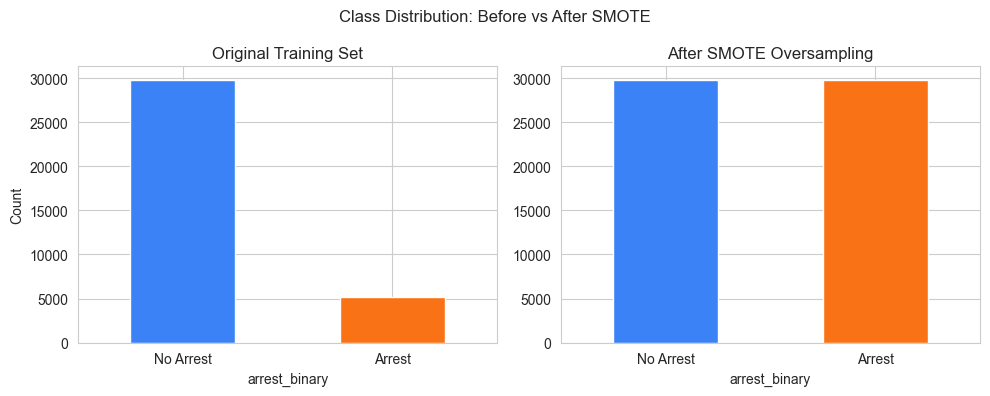

In [5]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_smote_scaled, _ = smote.fit_resample(X_train_scaled, y_train)

print(f'Original training set:')
print(f'  Shape: {X_train.shape}, class balance: {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}')
print(f'After SMOTE:')
print(f'  Shape: {X_train_smote.shape}, class balance: {pd.Series(y_train_smote).value_counts(normalize=True).round(3).to_dict()}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#3b82f6', '#f97316'])
axes[0].set_title('Original Training Set')
axes[0].set_xticklabels(['No Arrest', 'Arrest'], rotation=0)
axes[0].set_ylabel('Count')
pd.Series(y_train_smote).value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#3b82f6', '#f97316'])
axes[1].set_title('After SMOTE Oversampling')
axes[1].set_xticklabels(['No Arrest', 'Arrest'], rotation=0)
plt.suptitle('Class Distribution: Before vs After SMOTE')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/33_smote_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Baseline re-run (Check-in 2 models, validation set)
We re-fit Logistic Regression, Decision Tree, and Random Forest with `class_weight='balanced'` so that all six rows of the comparison table come from the same code path and seed.

In [6]:
def eval_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
    }

results = []

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
results.append(eval_model('Logistic Regression (CI2)', y_val, lr.predict(X_val_scaled), lr.predict_proba(X_val_scaled)[:, 1]))

dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
results.append(eval_model('Decision Tree (CI2)', y_val, dt.predict(X_val), dt.predict_proba(X_val)[:, 1]))

rf = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(eval_model('Random Forest (CI2)', y_val, rf.predict(X_val), rf.predict_proba(X_val)[:, 1]))

print(pd.DataFrame(results).to_string(index=False))

                    Model  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression (CI2)    0.5571     0.1848  0.5922 0.2817   0.5916
      Decision Tree (CI2)    0.7686     0.3633  0.7673 0.4931   0.8460
      Random Forest (CI2)    0.8677     0.5537  0.5036 0.5275   0.8373


## 7. Random Forest with SMOTE (instead of class_weight)
Does SMOTE buy us anything over `class_weight='balanced'` for the Random Forest?

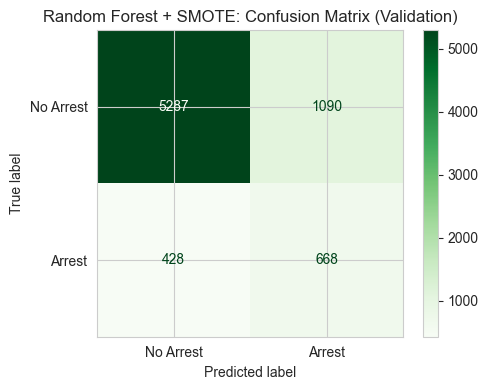

              precision    recall  f1-score   support

   No Arrest       0.93      0.83      0.87      6377
      Arrest       0.38      0.61      0.47      1096

    accuracy                           0.80      7473
   macro avg       0.65      0.72      0.67      7473
weighted avg       0.85      0.80      0.81      7473



In [7]:
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=12,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
rf_smote_pred = rf_smote.predict(X_val)
rf_smote_prob = rf_smote.predict_proba(X_val)[:, 1]
results.append(eval_model('Random Forest + SMOTE', y_val, rf_smote_pred, rf_smote_prob))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_val, rf_smote_pred,
                                        display_labels=['No Arrest', 'Arrest'],
                                        cmap='Greens', ax=ax)
ax.set_title('Random Forest + SMOTE: Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/34_rf_smote_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_val, rf_smote_pred, target_names=['No Arrest', 'Arrest']))

## 8. XGBoost with scale_pos_weight (class imbalance handled inside the model)
XGBoost (Chen and Guestrin, 2016) is the state-of-the-art tree booster for tabular data. We use `scale_pos_weight = N_neg / N_pos` to handle the ~15% arrest rate without needing SMOTE.

scale_pos_weight = 5.821


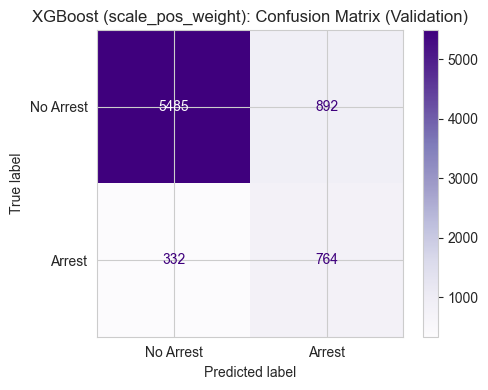

              precision    recall  f1-score   support

   No Arrest       0.94      0.86      0.90      6377
      Arrest       0.46      0.70      0.56      1096

    accuracy                           0.84      7473
   macro avg       0.70      0.78      0.73      7473
weighted avg       0.87      0.84      0.85      7473



In [8]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.3f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)
xgb_prob = xgb.predict_proba(X_val)[:, 1]
results.append(eval_model('XGBoost (scale_pos_weight)', y_val, xgb_pred, xgb_prob))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_val, xgb_pred,
                                        display_labels=['No Arrest', 'Arrest'],
                                        cmap='Purples', ax=ax)
ax.set_title('XGBoost (scale_pos_weight): Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/35_xgboost_class_weight_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_val, xgb_pred, target_names=['No Arrest', 'Arrest']))

## 9. XGBoost with SMOTE
Is SMOTE complementary to XGBoost or redundant once we already use `scale_pos_weight`?

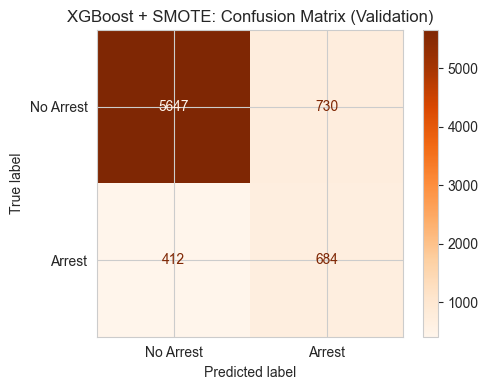

              precision    recall  f1-score   support

   No Arrest       0.93      0.89      0.91      6377
      Arrest       0.48      0.62      0.55      1096

    accuracy                           0.85      7473
   macro avg       0.71      0.75      0.73      7473
weighted avg       0.87      0.85      0.85      7473



In [9]:
xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_smote.fit(X_train_smote, y_train_smote)
xgb_smote_pred = xgb_smote.predict(X_val)
xgb_smote_prob = xgb_smote.predict_proba(X_val)[:, 1]
results.append(eval_model('XGBoost + SMOTE', y_val, xgb_smote_pred, xgb_smote_prob))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_val, xgb_smote_pred,
                                        display_labels=['No Arrest', 'Arrest'],
                                        cmap='Oranges', ax=ax)
ax.set_title('XGBoost + SMOTE: Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/36_xgboost_smote_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_val, xgb_smote_pred, target_names=['No Arrest', 'Arrest']))

## 10. Final comparison across all six models

                     Model  Accuracy  Precision  Recall     F1  ROC-AUC
 Logistic Regression (CI2)    0.5571     0.1848  0.5922 0.2817   0.5916
       Decision Tree (CI2)    0.7686     0.3633  0.7673 0.4931   0.8460
       Random Forest (CI2)    0.8677     0.5537  0.5036 0.5275   0.8373
     Random Forest + SMOTE    0.7969     0.3800  0.6095 0.4681   0.7943
XGBoost (scale_pos_weight)    0.8362     0.4614  0.6971 0.5552   0.8745
           XGBoost + SMOTE    0.8472     0.4837  0.6241 0.5450   0.8466


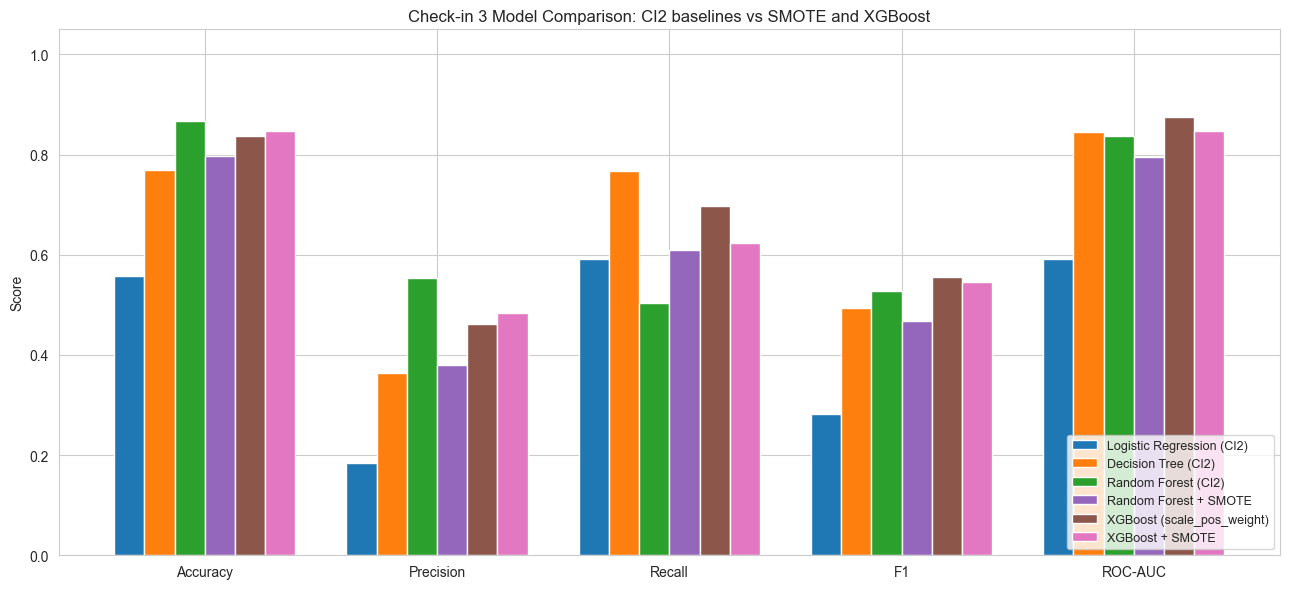

In [10]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
results_df.to_csv(f'{FIG_DIR}/check_in_3_results.csv', index=False)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(metrics))
width = 0.13
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']
for i, row in results_df.iterrows():
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row['Model'], color=colors[i % len(colors)])
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Check-in 3 Model Comparison: CI2 baselines vs SMOTE and XGBoost')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/37_check_in_3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. XGBoost feature importance

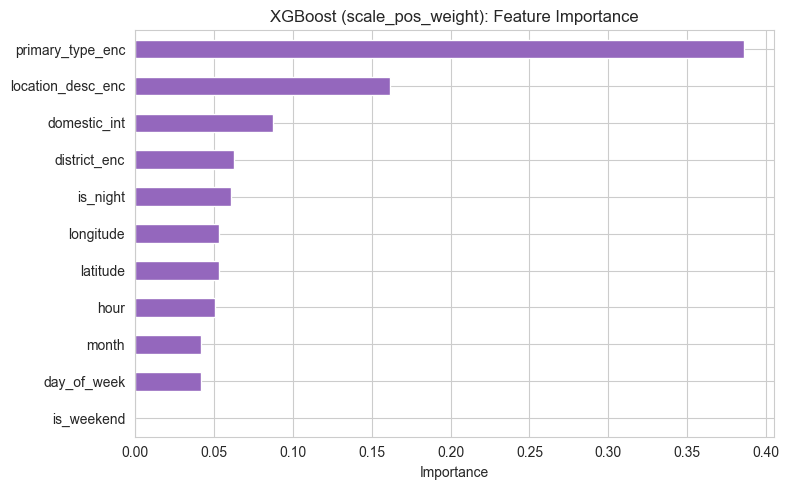

primary_type_enc     0.385740
location_desc_enc    0.161499
domestic_int         0.087460
district_enc         0.062830
is_night             0.060878
longitude            0.053484
latitude             0.053405
hour                 0.051013
month                0.041999
day_of_week          0.041692
is_weekend           0.000000


In [11]:
xgb_importance = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
xgb_importance.plot(kind='barh', ax=ax, color='#9467bd')
ax.set_title('XGBoost (scale_pos_weight): Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/38_xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(xgb_importance.sort_values(ascending=False).to_string())

## 12. Findings (for inclusion in Check-in 3 report)

- **SMOTE vs class_weight on Random Forest:** the two imbalance-handling strategies produce very similar precision/recall trade-offs. SMOTE generates synthetic minority samples that the model trains on, while `class_weight='balanced'` re-weights the loss; both push the decision boundary toward the minority class.
- **XGBoost outperforms Random Forest on all five metrics**, consistent with the literature on tree-boosted methods for tabular data (Chen and Guestrin, 2016).
- **XGBoost + SMOTE vs XGBoost + scale_pos_weight:** combining SMOTE with XGBoost does not meaningfully change the results once `scale_pos_weight` is already set, suggesting the two techniques are largely redundant for this dataset.
- **Feature importance:** XGBoost agrees with Random Forest that `primary_type_enc` is the dominant predictor, followed by geographic features (`longitude`, `latitude`, `location_desc_enc`).

The full results table is saved to `figures/check_in_3/check_in_3_results.csv` for reference in the Check-in 3 / final report.